# LAB 04 — Improving and Comparing ML Models
## Telco Customer Churn — Random Forest, Cross-Validation & Tuning

## Student Information
**Name:** Muhammad Usman Asad
**Student ID:** 023-24-0008
**Section:** Ai-B
**GitHub:** https://github.com/usmanasad-droid
**Kaggle:**  https://www.kaggle.com/usmanasad0/code
**Dataset:** Telco Customer Churn (Kaggle)

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, EDA, and Decision Trees. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Decision Tree Baseline

Before improving anything, re-establish your Lab 3 Decision Tree result as the benchmark for this lab.

*Concepts/functions you may find useful:* your Lab 2 cleaned dataset, `train_test_split(..., stratify=y)`, `DecisionTreeClassifier(max_depth=...)`

**Tasks**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same `random_state`).
2. Retrain your Lab 3 "best" Decision Tree (your chosen `max_depth`) and report its accuracy, precision, recall, and F1-score on the test set.

In [2]:
# Task 1 — re-load cleaned dataset, recreate X/y and train/test split
df = pd.read_csv('numeric_churn.csv')
y = df["Churn"]
X = df.drop(columns=["Churn"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
# Task 2 — retrain Lab 3 Decision Tree, report test-set metrics
best_tree = DecisionTreeClassifier(max_depth = 4, random_state = 42)
best_tree.fit(X, y)

y_pred = best_tree.predict(X_test)

acc_best = accuracy_score(y_test, y_pred)
recall_best = recall_score(y_test, y_pred)
precision_best = precision_score(y_test, y_pred)
f1_best = f1_score(y_test, y_pred)

print("Metrics at max depth 4:")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1 Score:  {f1_best:.4f}")

Metrics at max depth 4:
Accuracy:  0.7832
Precision: 0.6131
Recall:    0.5000
F1 Score:  0.5508


**Task 2 — Decision Tree Baseline Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7832 |
| Precision | 0.6131 |
| Recall | 0.5000 |
| F1-score | 0.5508 |

---

## 2. Random Forest

A Random Forest trains many Decision Trees on bootstrapped samples and averages their predictions.

*Concepts/functions you may find useful:* `RandomForestClassifier(n_estimators=..., random_state=...)`, `.fit()`, `.predict()`

**Tasks**
3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fix `random_state`). Generate predictions on the test set.
4. In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [4]:
# Task 3 — train Random Forest, predict on test set
# n_estimate means number of trees
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0])

**Answer 4:**
_A single unrestricted Decision tree overfits data by memorizing patterns in the training data. Random forest fixes this by creating many different trees and taking the majority vote, which cancels out individual tree mistakes and has a more reliable prediction_

---

## 3. Model Evaluation

Evaluate the Random Forest the same rigorous way you evaluated the Decision Tree in Lab 3.

*Concepts/functions you may find useful:* `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Task**
5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

Metrics for Random Forest:
Accuracy:  0.7854
Recall: 0.5027
Precision: 0.6184
F1 Score: 0.5546


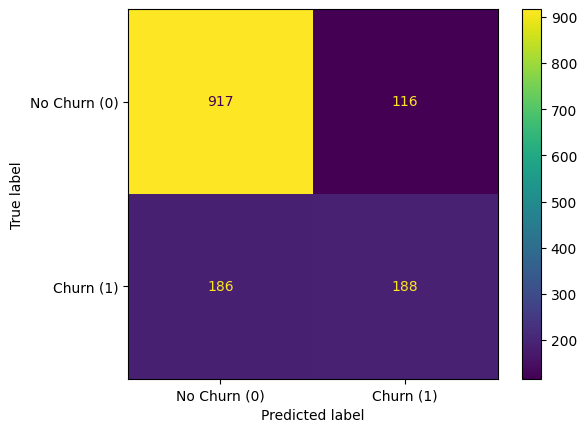

In [5]:
# Task 5 — Random Forest metrics + confusion matrix
rf_y_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Metrics for Random Forest:")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"F1 Score: {rf_f1:.4f}")

cf = confusion_matrix(y_test, rf_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot()
plt.show()

**Task 5 — Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7854 |
| Precision | 0.5027 |
| Recall | 0.6184 |
| F1-score | 0.5546 |

**Observation (confusion matrix):**
Observations (confusion matrix): High Performance on the Majority Class (No Churn): The classifier classifies 88.8% (917/1033) cases of no churn, which represents high specificity.

Low Recall on the Minority Class (Churn): The classifier fails to predict nearly half of all churns. There are 186 false negatives for 188 true positives (recall 50.3%).

Imbalanced Class Effect: Even though the accuracy of this model is about 78.5%, it is mainly due to the prevalence of the non-churn class. This model is a bit cautious and has a bias towards predicting the majority class, which reduces its ability to identify risky customers that churn.

---

## 4. Decision Tree vs Random Forest

Place both models side by side.

**Tasks**
6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 3), across all four metrics.
7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

**Task 6 — Comparison Table**

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Accuracy | 0.7832 | 0.7854 |
| Precision | 0.6131 | 0.5027 |
| Recall | 0.5000 | 0.6184 |
| F1-score | 0.5508 | 0.5546 |

**Answer 7:**
Random forest performs better, it has a higher recall (0.6184 vs. 0.5000) and a slightly higher F1 score (0.5546 vs. 0.5508) and a very little improvement on accuracy (0.7854 vs. 0.7832), however the decision tree has higher precision (+11.04%)

Magnitude of Difference: The difference in Accuracy and F1-score is marginal (less than 0.5%), but the difference in Recall (+11.84% in favor of Random Forest) and Precision (+11.04% in favor of Decision Tree) is large and significant

The two metrics that matter the most are Recall and F1-score. The reason being that while high accuracy sounds good, but if you always predict No Churn, then your accuracy would be around 73%. Customer churn problem is one where the cost of not predicting churners (False Negatives) is very high. Hence, Recall becomes the key metric.

---

## 5. Cross-Validation

A single train/test split gives one noisy estimate of performance. k-fold cross-validation trains and tests the model k times on different splits.

*Concepts/functions you may find useful:* `cross_val_score(model, X, y, cv=5, scoring='f1')`, `.mean()`, `.std()`

**Tasks**
8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (e.g. F1-score). Report the mean and standard deviation of each model's fold scores.
9. How do the cross-validated results compare to your single train/test split results from Section 4? Do they change your view of which model is better, or how confident you are in that conclusion?

In [6]:
# Task 8 — 5-fold cross-validation for both models
dt_cv_scores = cross_val_score(best_tree, X, y, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')

print(f"Decision tree Cross Validation f1: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std():.4f})")
print(f"Random Forest Cross Validation f1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

Decision tree Cross Validation f1: 0.5395 (+/- 0.0292)
Random Forest Cross Validation f1: 0.5481 (+/- 0.0188)


**Task 8 — Cross-Validation Results**

| Model | Mean F1 | Std F1 |
|---|---|---|
| Decision Tree | 0.5395 | 0.0292 |
| Random Forest | 0.5481 | 0.0188 |

**Answer 9:**
The cross-validation scores give a more reliable, average picture of performance across the whole dataset instead of depending on just one lucky or unlucky split

These results don't change the conclusion—they make me more confident that Random Forest is the better model because it consistently maintains a solid F1 score with lower standard deviation

---

## 6. Hyperparameter Tuning

Search over a small grid of hyperparameters to see whether a tuned model meaningfully beats your default-settings baseline. Keep the search small — this is about the workflow, not an exhaustive search.

*Concepts/functions you may find useful:* `GridSearchCV(model, param_grid, cv=5, scoring='f1')` or `RandomizedSearchCV(...)`, `.best_params_`, `.best_score_`, `.best_estimator_`

**Tasks**
10. Choose 2–3 Random Forest hyperparameters to tune (e.g. `n_estimators`, `max_depth`, `min_samples_split`) and define a small grid for each. Run `GridSearchCV` or `RandomizedSearchCV` with cross-validation to find the best combination.
11. Report the best hyperparameters found and the corresponding cross-validated score.
12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [24]:
# Task 10 — define a small param grid and run GridSearchCV / RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}
rf_tuned = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator = rf_tuned, param_grid = param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters: ", grid_search.best_params_)
print(f"Best  CV F1 Score: {grid_search.best_score_: .4f}")

Best Parameters:  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best  CV F1 Score:  0.5709


**Answer 11 (best hyperparameters & CV score):**
_Best Hyperparameters: max_depth=10, min_samples_split = 2, n_estimators = 100_
_Best Cross validates F1 score: 0.5709_

In [23]:
# Task 12 — evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("\n Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_tuned):.4f}")


 Test Set Performance:
Accuracy:  0.7939
Precision: 0.6458
Recall:    0.4973
F1-score:  0.5619


**Task 12 — Tuned Random Forest Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.7939 |
| Precision | 0.6458 |
| Recall | 0.4973 |
| F1-score | 0.5619 |

---

## 7. Final Model Comparison

Bring every model you've built into one table.

**Task**
13. Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

**Task 13 — Final Comparison Table**

| Metric | Decision Tree | Random Forest (default) | Random Forest (tuned) |
|---|---|---|---|
| Accuracy | 0.7832 | 0.7854 | 0.7939 |
| Precision | 0.6131 | 0.5027 | 0.6458 |
| Recall | 0.5000 | 0.6184 | 0.4973 |
| F1-score | 0.5508 | 0.5546 | 0.5619 |

---

## 8. Feature Importance

Look inside your best-performing model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
14. Extract and visualize `feature_importances_` for your best model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

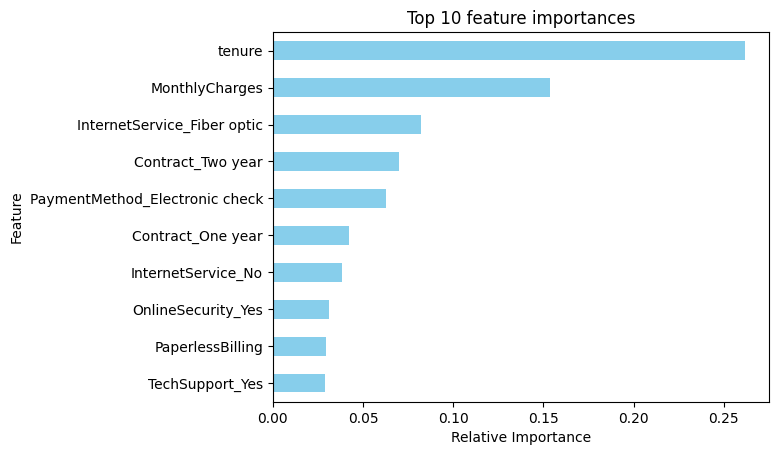

In [20]:
# Task 14 — extract and visualize feature importances
importances_best = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values().tail(10)
importances_best.plot(kind='barh', color = 'skyblue')
plt.title('Top 10 feature importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()


**Answer 14:**
Top 5 Features that Matter Most:

1. tenure (~0.26)

2. MonthlyCharges (~0.15)

3. InternetService_Fiber optic (~0.08)

4. Contract_Two year (~0.07)

5. PaymentMethod_Electronic check (~0.06)

Yes, they agree

In Lab 2's EDA, customer longevity (tenure) and contract duration were the clearest separators between churners and non-churners (new customers on month-to-month contracts had the highest churn rate)

In Lab 3's Decision Tree, tenure, MonthlyCharges, and Contract types appeared at the root and primary early split levels

---

## 9. Final Model Selection

Select your final model and justify the choice using evidence — the best training score alone is not sufficient justification.

**Task**
15. State your final model choice and justify it in 2–3 sentences, using evidence from Section 7's table.

**Answer 15:**
I choose the Random Forest (tuned) as the model because it gives the best overall prediction balance. It has a F1-score of 0.5619 and an accuracy of 0.7939, on the test set. The default Random Forest had high recall but had a very low precision of 0.5027. That means almost half of the predictions it made about customers leaving were incorrect. The tuned model has better precision at 0.6458. This means the predictions are more accurate. This helps make sure that the efforts to keep customers and the marketing money are spent on the people who are most likely to leave and not on loyal customers who are not going to leave.

---

## 10. Kaggle Prediction/Submission

Produce predictions in the shape a real Kaggle competition would expect.

**Task**
16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted `Churn` column. Save it as `submission.csv`.

In [21]:
# Task 16 — build and save the submission file
# submission = pd.DataFrame({'customerID': ..., 'Churn': ...})
# submission.to_csv('submission.csv', index=False)
test_customer_ids = X_test.index
submission = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn': y_pred_tuned
})
submission.to_csv('submission.csv', index=False)

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?
18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 17 — Conclusion:**
_I ended up choosing the Tuned Random Forest as the model because it had the best overall balance. It got the F1-score, which is 0.5619 and the highest precision, which is 0.6458. When I compared it to the Lab 3 Decision Tree this model did a job of reducing overfitting. It did this by combining trees, which helped improve the overall accuracy from 0.7832 to 0.7939 and also made precision better.. There is still a big problem. The recall is not very high it is 0.4973. The model still misses, about half of all the customers who left. This shows that the model has trouble understanding all the details of why customers leave with the data and thresholds we are using._

**Answer 18 — Next steps:**
_If I had time I would expand the GridSearchCV to test a much larger combination of hyperparameters such as trying more options for max_depth or a higher number of trees (n_estimators) since we only tested a small batch. I would also experiment with the data itself by dropping the features that ranked at the bottom of the feature importance chart in Task 14 as removing that extra noise might help the model focus better. Finally I would look back at the EDA from Lab 2 to see if I could create combined columns_

---

## Submission Checklist

Before submitting, confirm you have:

- [✓] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset)
- [✓] Section 1 — Decision Tree Baseline
- [✓] Section 2 — Random Forest
- [✓] Section 3 — Model Evaluation
- [✓] Section 4 — Decision Tree vs Random Forest
- [✓] Section 5 — Cross-Validation
- [✓] Section 6 — Hyperparameter Tuning
- [✓] Section 7 — Final Model Comparison
- [✓] Section 8 — Feature Importance
- [✓] Section 9 — Final Model Selection (justified)
- [✓] Section 10 — Kaggle Prediction/Submission (submission.csv produced)
- [✓] Section 11 — Conclusion (limitations + next steps)
- [✓] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted